# 📊 [소둔로(CAL01 / CR1) 온도 데이터 및 정비·교체 이력 분석]

> **💡 안내:** 본 문서는 **소둔로(CAL01 / CR1) 온도 센서 데이터**를 중심으로 정기수리, 설비·조업·정비 및 부품교체 이력 데이터를 연계하여, **온도 데이터의 이상 및 결측 현상을 파악하고 그 발생 시점과 설비·정비 이력 간의 시간적 관계를 분석**하는 작업 공간입니다.
>
> 데이터 탐색 및 전처리부터 가설 설정·검증, 파생변수 생성, 모델링 및 결과 평가까지의 전체 분석 과정을 단계적으로 구성하여, **분석 결과와 그 근거를 일관된 흐름으로 확인할 수 있도록 작성하였습니다.**
---

## 📑 목차 (Table of Contents)

- **CHAPTER 0** : 오늘의 분석 지도 및 개요
- **CHAPTER 1** : 데이터 불러오기 및 기초 탐색 (EDA)
- **CHAPTER 2** : 데이터 전처리 및 정제 (Pre-processing)
- **CHAPTER 3 🌟** : 파생변수 생성 및 특징 엔지니어링 (Feature Engineering)
  - 3.1 도메인 특성 반영 변수
  - 3.2 이동 통계 및 시계열 변화량 계산
  - 3.3 파생변수 정합성 검증 및 결측치 처리
- **부록 A** : 핵심 함수 및 치트시트
---

## 🔄 전체 분석 진행 순서 (Workflow)

0. **분석 개요 및 지도 (CHAPTER 0)**
   - 본 분석의 목적, 활용 데이터 및 전체 작업 공간 안내

1. **데이터 이해 및 EDA**
   - 각 센서/컬럼의 의미 확인 및 기초 통계 분석

2. **전처리 및 정렬**
   - 결측치 처리, 불필요한 노이즈 필터링 및 시간/시퀀스 순서 정렬

3. **파생변수 생성 (Feature Engineering)**
   - 모델이 설비의 상태 변화나 패턴을 더 잘 학습할 수 있도록 의미 있는 변수 추가
---

## 📌 CHAPTER 0 : 오늘의 분석 지도 및 개요

- **분석 배경 및 목적:** 소둔로(CAL01 / CR1) 온도 센서 데이터를 중심으로 정기수리, 설비·조업·정비 및 부품교체 이력을 연계하여 온도 데이터의 이상 및 결측 현상을 파악하고, 해당 현상과 설비·정비 이력 간의 시간적 관계 및 연관성을 분석한다.

- **진행 방향:** 본 문서는 데이터 탐색 및 전처리부터 가설 설정·검증, 파생변수 생성 및 검증까지의 과정을 단계적으로 구성하여, 각 분석 결과와 그 근거를 일관된 흐름으로 확인할 수 있도록 작성한다.

---

In [ ]:
# 이 칸은 그대로 실행하세요. 데이터 경로와 그래프 한글 폰트를 잡아둡니다.
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

DATA_DIR = os.path.join("..", "data")          # notebooks 폴더 기준 한 단계 위의 data 폴더
FIG_DIR = os.path.join("..", "figures")        # 그래프 저장 위치
os.makedirs(FIG_DIR, exist_ok=True)

# 기존 3개 (T- 센서 계측, G-02 사건 기록, G-01 기준 정보)
TEMP_CSV = os.path.join(DATA_DIR, "T-CR1-CAL01_온도.csv")          # 소둔로 온도·제어출력, 1초 주기
EVENT_CSV = os.path.join(DATA_DIR, "G-02_조업이벤트.csv")           # 강종변경 등, PLANT_CD 단위
REPAIR_CSV = os.path.join(DATA_DIR, "G-01_정기수리캘린더.csv")       # 계획 정지, PLANT_CD 단위

# 2026-09-28 추가된 4개 (상위 이슈 #43)
EQP_CSV = os.path.join(DATA_DIR, "G-01_설비마스터.csv")             # 설비 사전, 키 EQP_TAG
PART_CSV = os.path.join(DATA_DIR, "G-01_부품마스터.csv")            # 부품 사전, 키 PART_CD
MAINT_CSV = os.path.join(DATA_DIR, "G-02_정비이력.csv")             # 정비·고장 기록, 키 WO_NO + EQP_TAG
PARTCHG_CSV = os.path.join(DATA_DIR, "G-02_부품교체이력.csv")        # 부품 교체, 키 WO_NO + PART_CD

ENC = "utf-8-sig"                              # G- 로 시작하는 마스터 CSV는 BOM 있음

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# 그래프 한글 깨짐 방지 - 설치된 폰트 중 있는 것을 골라 rcParams에 넣습니다
installed = {f.name for f in font_manager.fontManager.ttflist}
for cand in ["Malgun Gothic", "AppleGothic", "NanumGothic", "NanumBarunGothic", "Noto Sans CJK KR"]:
    if cand in installed:
        rcParams["font.family"] = cand
        break
else:
    print("경고: 한글 폰트를 못 찾았습니다. 그래프의 한글이 □ 로 보일 수 있습니다.")

rcParams["axes.unicode_minus"] = False         # 음수 기호가 □ 로 나오는 것 방지
rcParams["figure.dpi"] = 110

In [ ]:
# 데이터 불러오기
df_temp = pd.read_csv(TEMP_CSV, parse_dates=["MEAS_DT"])  # 💡 날짜/시간 컬럼 바로 파싱
df_event = pd.read_csv(EVENT_CSV, encoding=ENC)
df_repair = pd.read_csv(REPAIR_CSV, encoding=ENC)
df_eqp = pd.read_csv(EQP_CSV, encoding=ENC)
df_part = pd.read_csv(PART_CSV, encoding=ENC)
df_maint = pd.read_csv(MAINT_CSV, encoding=ENC)
df_partchg = pd.read_csv(PARTCHG_CSV, encoding=ENC)

# 데이터 크기 및 상위 행 확인
print("온도 데이터 크기:", df_temp.shape)
print("MEAS_DT 데이터 타입:", df_temp["MEAS_DT"].dtype)  # 💡 타입 확인용 출력 추가
df_temp.head()

===== 온도 데이터 기본 정보 =====

온도 데이터 크기: (345390, 24)
<br>`MEAS_DT` 데이터 타입: datetime64[us]

<br>
===== 온도 데이터 샘플 (상위 5개 행) =====

| MEAS_DT | LOT_NO | CLN-IN | TC-Z1 | TC-Z2 | OP-Z1 | OP-Z2 | TC-Z3 | TC-Z4 | TC-Z5 | TC-Z6 | OP-Z3 | OP-Z4 | OP-Z5 | OP-Z6 | CP-Z4 | CP-Z4M | TC-Z7 | TC-Z8 | TC-Z9 | OP-Z7 | OP-Z8 | TC-OUT1 | TC-OUT2 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 2024-01-02 03:36:00 | 240001 | 69.0111 | 100.559 | 99.7062 | 66.6165 | 18.5975 | 859.683 | 860.800 | 860.367 | 860.126 | 83.9075 | 47.2134 | 51.6966 | 69.0189 | 0.449234 | 1.151760e-10 | 331.202 | 331.335 | 327.550 | 65.4737 | 56.2615 | 291.906 | 287.039 |
| 2024-01-02 03:36:01 | 240001 | 69.0724 | 100.497 | 99.6447 | 73.2873 | 20.9099 | 859.621 | 860.737 | 860.429 | 860.126 | 88.8233 | 48.6681 | 50.1850 | 69.0560 | 0.449334 | 1.152830e-10 | 331.202 | 331.335 | 327.550 | 65.4737 | 56.2615 | 291.906 | 287.039 |
| 2024-01-02 03:36:02 | 240001 | 68.9497 | 100.497 | 99.7062 | 70.7377 | 20.9651 | 859.683 | 860.737 | 860.367 | 860.126 | 84.2600 | 48.5541 | 51.7643 | 69.0900 | 0.449717 | 1.151760e-10 | 331.202 | 331.274 | 327.489 | 65.4737 | 56.2615 | 291.845 | 287.039 |
| 2024-01-02 03:36:03 | 240001 | 68.8884 | 100.497 | 99.7062 | 70.4484 | 18.7313 | 859.683 | 860.675 | 860.367 | 860.188 | 84.5850 | 49.9122 | 51.7661 | 67.6582 | 0.449888 | 1.151760e-10 | 331.202 | 331.274 | 327.489 | 66.5701 | 56.2615 | 291.845 | 287.039 |
| 2024-01-02 03:36:04 | 240001 | 68.8884 | 100.436 | 99.7062 | 70.0716 | 21.1505 | 859.683 | 860.737 | 860.367 | 860.126 | 84.8836 | 48.2923 | 51.7676 | 70.7738 | 0.449992 | 1.151760e-10 | 331.202 | 331.214 | 327.550 | 65.4737 | 56.2615 | 291.845 | 287.039 |


---

## 🖼️ 개요 및 참고 이미지
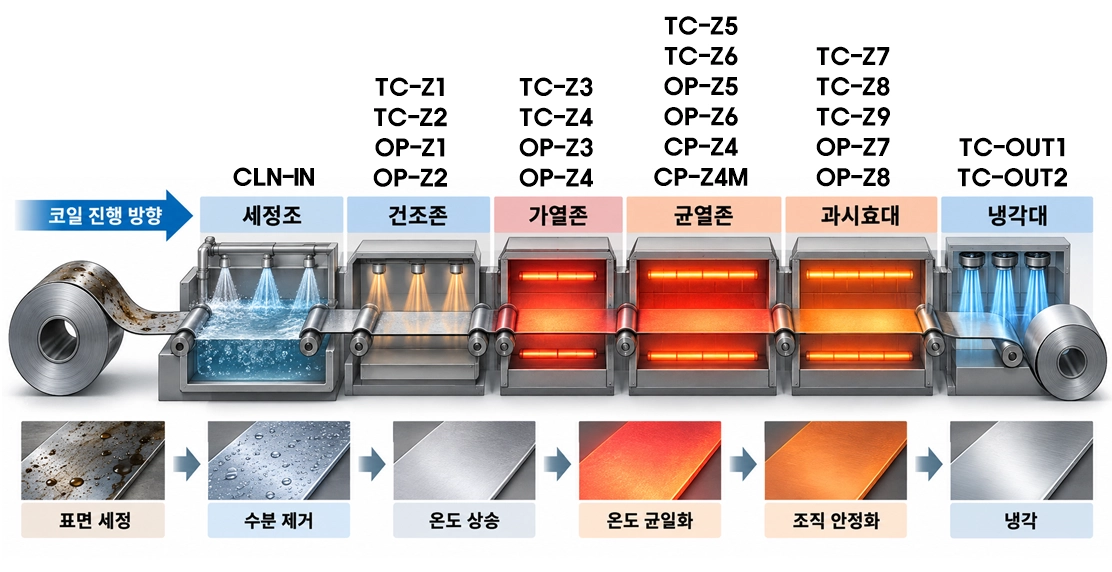
<br>*<u>제1냉연(CR1)</u> 공장의 핵심 설비인 <u>연속소둔로 1호기(CAL01)</u>의 전체 공정 흐름을 나타낸 것*

---

## 📌 CHAPTER 1 : 데이터 불러오기 및 기초 탐색 (EDA)

- **목표:** 로드한 7개 데이터셋의 구조(`shape`), 컬럼 및 데이터 타입, 결측치, 기초 통계량과 시간 정보 등을 확인하여 각 데이터의 특성을 파악합니다.
- **주요 탐색 내용:**
  - 온도 데이터(`df_temp`)의 측정 시점 및 시간 구간과 결측 여부 확인
  - 설비·정비·부품 관련 데이터의 구조 및 결측치 확인
  - 데이터 간 연결에 사용할 주요 키(`EQP_TAG`, `PART_CD`, `WO_NO`) 확인
  - 각 시계열 데이터의 수집 기간 및 시간축 보유 여부 비교

In [ ]:
# 각 데이터프레임의 기본 정보(.info()) 및 결측치 확인
datasets = {
    "온도 데이터": df_temp,
    "조업이벤트": df_event,
    "정기수리캘린더": df_repair,
    "설비마스터": df_eqp,
    "부품마스터": df_part,
    "정비이력": df_maint,
    "부품교체이력": df_partchg
}

for name, df in datasets.items():
    print(f"[{name}] 크기: {df.shape}")
    display(df.head(2))
    print("-" * 50)


===== 전체 데이터셋 샘플 요약 =====

온도 데이터 (크기: 345390, 24)
| MEAS_DT | LOT_NO | CLN-IN | TC-Z1 | TC-Z2 | OP-Z1 | OP-Z2 | ... | TC-OUT2 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 2024-01-02 03:36:00 | 240001 | 69.0111 | 100.559 | 99.7062 | 66.6165 | 18.5975 | ... | 287.039 |
| 2024-01-02 03:36:01 | 240001 | 69.0724 | 100.497 | 99.6447 | 73.2873 | 20.9099 | ... | 287.039 |

조업이벤트 (크기: 263, 6)
| EVT_ID | EVT_DT | EVT_TYPE | PLANT_CD | BEF_VAL | AFT_VAL |
| :--- | :--- | :--- | :--- | :--- | :--- |
| EVT-2024-0001 | 2024-01-02 03:36 | 강종변경 | CR1 | SPCC | SGCC |
| EVT-2024-0002 | 2024-01-05 23:46 | 강종변경 | CR1 | SGCC | SPFH590 |

정기수리캘린더 (크기: 4, 5)
| PLAN_ID | PLANT_CD | STRT_DT | END_DT | SCOPE |
| :--- | :--- | :--- | :--- | :--- |
| PLAN-2024-01 | SP1 | 2024-03-15 | 2024-03-22 | 배풍기 정지 및 소결기 정기점검 |
| PLAN-2024-02 | CR1 | 2024-06-10 | 2024-06-14 | 연속소둔로 노내 정비 |

설비마스터 (크기: 104, 12)
| EQP_TAG | EQP_NM | PARENT_TAG | PLANT_CD | EQP_TYPE | ... | DATA_AVL_YN |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| P1-BF1 | 제1고로 | NaN | BF1 | 라인 | ... | N |
| P1-BF1-BFR01 | 고로 본체 | P1-BF1 | BF1 | 고로 | ... | N |

부품마스터 (크기: 129, 6)
| PART_CD | PART_NM | PART_TYPE | APPLY_EQP_TYPE | STD_LIFE_H | LEAD_TIME_D |
| :--- | :--- | :--- | :--- | :--- | :--- |
| BRG-001 | 베어링 6206 | 베어링류 | 공통 | 31000 | 33 |
| BRG-002 | 베어링 6210 | 베어링류 | 공통 | 24000 | 17 |

정비이력 (크기: 2112, 12)
| WO_NO | EQP_TAG | DETC_DT | STRT_DT | END_DT | ... | REMARK |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| WO-2024-00001 | P1-SM1-CRN02 | 2024-01-01 06:22 | 2024-01-01 07:28 | 2024-01-01 11:27 | ... | 점검 이상없음 |
| WO-2024-00002 | P1-CC1-SCC01 | 2024-01-01 06:35 | 2024-01-01 12:27 | 2024-01-01 14:25 | ... | 1호기 재발, 제어 이상 |

부품교체이력 (크기: 427, 4)
| WO_NO | PART_CD | QTY | CHG_RSN |
| :--- | :--- | :--- | :--- |
| WO-2024-00005 | INS-004 | 3 | 예방 |
| WO-2024-00011 | CWP-002 | 1 | 수명도래 |

---
## 📌 CHAPTER 2 : 데이터 전처리 및 정제 (Pre-processing)

- **목표:** 시계열 분석과 이후 데이터 연계를 위해 주요 데이터의 시간 형식과 정렬 상태를 정리하고, 분석에 필요한 데이터 품질을 점검한다.

- **주요 작업:**
  - `MEAS_DT` 등 시간 컬럼을 `datetime` 형식으로 통일
  - 온도 데이터를 측정 시각(`MEAS_DT`) 기준으로 정렬하고 인덱스를 재설정
  - 결측치 및 데이터 공백 구간의 상태를 확인하고 분석 시 처리 기준을 설정
  - 정비·조업·정기수리 데이터의 시간 컬럼과 기간을 확인하여 이후 시간 기반 연계에 사용할 수 있도록 준비

In [ ]:
# 온도 데이터의 측정 일시(MEAS_DT)를 datetime 타입으로 변환 및 정렬
df_temp['MEAS_DT'] = pd.to_datetime(df_temp['MEAS_DT'])
df_temp = df_temp.sort_values('MEAS_DT').reset_index(drop=True)

print("전처리 후 온도 데이터 기간:", df_temp['MEAS_DT'].min(), "~", df_temp['MEAS_DT'].max())
df_temp.info()

In [ ]:
"""
전처리 후 온도 데이터 기간: 2024-01-02 03:36:00 ~ 2024-12-28 16:44:24
<class 'pandas.DataFrame'>
RangeIndex: 345390 entries, 0 to 345389
Data columns (total 24 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   MEAS_DT  345390 non-null  datetime64[us]
 1   LOT_NO   345390 non-null  int64         
 2   CLN-IN   345386 non-null  float64       
 3   TC-Z1    345371 non-null  float64       
 4   TC-Z2    345367 non-null  float64       
 5   OP-Z1    345390 non-null  float64       
 6   OP-Z2    345390 non-null  float64       
 7   TC-Z3    345385 non-null  float64       
 8   TC-Z4    345378 non-null  float64       
 9   TC-Z5    345375 non-null  float64       
 10  TC-Z6    345374 non-null  float64       
 11  OP-Z3    345136 non-null  float64       
 12  OP-Z4    345390 non-null  float64       
 13  OP-Z5    345390 non-null  float64       
 14  OP-Z6    345390 non-null  float64       
 15  CP-Z4    345390 non-null  float64       
 16  CP-Z4M   345377 non-null  float64       
 17  TC-Z7    345368 non-null  float64       
 18  TC-Z8    345373 non-null  float64       
...
 22  TC-OUT1  345384 non-null  float64       
 23  TC-OUT2  345377 non-null  float64       
dtypes: datetime64[us](1), float64(22), int64(1)
memory usage: 63.2 MB
"""

### 사용할 CSV 데이터 및 시간대 보유 현황

| 데이터 파일 | 결측치 여부 | 시간 데이터 보유 | 시간 대표 컬럼 | 대조 및 활용 목적 |
| :--- | :---: | :---: | :---: | :--- |
| `G-01_부품마스터.csv` | 없음 | ✖️ | - | 부품 기준정보 참조 (마스터 데이터) |
| `G-01_설비마스터.csv` | 없음 | ✖️ | - | 설비 기준정보 참조 (마스터 데이터) |
| `G-01_정기수리캘린더.csv` | 없음 | ⭕ | `START_DATE` | 계획된 정기수리 일정 대조 |
| `G-02_부품교체이력.csv` | 없음 | ⭕ | `CHG_DT` | 실제 부품 교체 시점 대조 |
| `G-02_정비이력.csv` | 있음 (`FAIL_MODE`, `REMARK`) | ⭕ | `STRT_DT`, `END_DT` | 정비 작업 및 다운타임 구간 대조 |
| `G-02_조업이벤트.csv` | 없음 | ⭕ | `STRT_DT`, `END_DT` | 조업 중단/품종 교체 구간 대조 |
| `T-CR1-CAL01_온도.csv` | 있음 (연속 결측 구간) | ⭕ | `TIMESTAMP` | **주 분석 대상** (결측 원인 규명 및 파생변수 생성) |
---

### 4개 주요 시계열 데이터의 월별 발생 건수 및 시간대 비교

- **분석 목적**:
  - 시간 정보가 존재하는 5개 CSV 데이터의 **최초 시작 시각(Earliest Timestamp)** 을 탐색하고, 해당 시점부터 **월 단위(Monthly) 통합 시간축**을 생성합니다.
  - 각 데이터셋별 월별 발생 건수(레코드 수)를 시각화하여 **데이터 수집 집중 구간** 및 **데이터 간 시간대 불일치/공백 구간**을 직관적으로 비교합니다.

- **비교 대상 데이터 및 기준 시간 컬럼**:
  1. `G-01_정기수리캘린더.csv` (`START_DATE`)
  2. `G-02_부품교체이력.csv` (`CHG_DT`) *[제외]
  3. `G-02_정비이력.csv` (`STRT_DT`)
  4. `G-02_조업이벤트.csv` (`STRT_DT`)
  5. `T-CR1-CAL01_온도.csv` (`TIMESTAMP`)

### 📌 `G-02_부품교체이력.csv` 시각화 제외 사유

`G-02_부품교체이력.csv`는 **정비이력의 작업지시번호(`WO_NO`)와 연결되는 부품 교체 상세 데이터**입니다.

따라서 이번 **월별 시계열 비교에서는 독립적인 그래프로 표시하지 않고**, 다음과 같이 활용합니다.

* **이번 분석:** 정비이력의 월별 발생 추이를 기준으로 정비 활동의 시간적 변화를 확인
* **향후 분석:** `WO_NO`를 기준으로 정비이력과 부품교체이력을 연결하여 **정비 작업별 교체 부품 및 교체 사유**를 분석

> **즉, 부품교체이력은 독립적인 시계열 데이터라기보다 정비이력을 상세하게 설명하는 연계 데이터로 활용합니다.**


### 📌 결측치 확인 목적

각 CSV에서 **어떤 컬럼의 값이 누락되어 있는지** 확인한다.

> **주의:** 결측치가 있다고 해서 해당 기간에 작업이나 정비가 없었다는 의미는 아니다.
> 결측치는 **기록은 존재하지만 특정 항목의 값이 입력되지 않은 경우**를 의미한다.

또한 특정 기간에 데이터가 존재하지 않는 경우에도 이를 곧바로 **"해당 기간에 정비가 없었다"**&#xACE0; 해석하지 않는다.
필요한 경우 `정기수리캘린더`, `정비이력`, `조업이벤트`, `온도 데이터`를 서로 대조하여 실제 작업·운전·측정 여부를 확인한다.


In [ ]:
# 각 CSV 파일을 실제 변수에 로드
df_part_master = pd.read_csv(
    os.path.join(DATA_DIR, 'G-01_부품마스터.csv'),
    encoding=ENC
)

df_eqp_master = pd.read_csv(
    os.path.join(DATA_DIR, 'G-01_설비마스터.csv'),
    encoding=ENC
)

df_maintenance = pd.read_csv(
    os.path.join(DATA_DIR, 'G-02_정비이력.csv'),
    encoding=ENC
)

df_part_change = pd.read_csv(
    os.path.join(DATA_DIR, 'G-02_부품교체이력.csv'),
    encoding=ENC
)

# 시계열 분석에 필요한 데이터도 로드
df_event = pd.read_csv(EVENT_CSV, encoding=ENC)
df_repair = pd.read_csv(REPAIR_CSV, encoding=ENC)

# 주요 마스터 및 이력 데이터의 컬럼별 결측치 확인
data_dict = {
    "부품마스터": df_part_master,
    "설비마스터": df_eqp_master,
    "정비이력": df_maintenance,
    "부품교체이력": df_part_change
}

for name, df in data_dict.items():
    null_counts = df.isnull().sum().sum()
    print(f"[{name}] 전체 결측치 수: {null_counts:,}건")



|[csv데이터]|전체 결측치 수|
|---|:---:|
|[부품마스터]|0|
|[설비마스터]|91|
|[정비이력]|1535|
|[부품교체이력]|0|



In [ ]:
# ============================================================
# 4개 주요 시계열 데이터의 월별 발생 건수 및 수집 기간 비교
#
# 분석 범위
# 1. 정기수리     : 전체 데이터 / PLANT_CD별 색상
# 2. 정비이력     : P1-CR1-CAL01 / MNT_TYPE별 색상
# 3. 조업이벤트   : CR1 / EVT_TYPE별 색상
# 4. 온도         : T-CR1-CAL01 전체 측정 건수
#
# ※ pandas의 kind="bar" 대신 matplotlib의 x 좌표를
#    직접 지정하여 4개 그래프의 월 위치를 정확히 통일
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. 데이터 로드
# ------------------------------------------------------------

DATA_DIR = "../data"

TEMP_CSV   = os.path.join(DATA_DIR, "T-CR1-CAL01_온도.csv")
EVENT_CSV  = os.path.join(DATA_DIR, "G-02_조업이벤트.csv")
REPAIR_CSV = os.path.join(DATA_DIR, "G-01_정기수리캘린더.csv")
MAINT_CSV  = os.path.join(DATA_DIR, "G-02_정비이력.csv")

df_temp = pd.read_csv(TEMP_CSV)
df_event_raw = pd.read_csv(EVENT_CSV)
df_repair_raw = pd.read_csv(REPAIR_CSV)
df_maint_raw = pd.read_csv(MAINT_CSV)


# ------------------------------------------------------------
# 2. 분석 범위 설정
# ------------------------------------------------------------

# [1] 정기수리
# → 전체 데이터를 사용하여 CR1 / SP1 / SP2를 비교
df_repair = df_repair_raw.copy()

# [2] 정비이력
# → 온도 데이터와 동일한 CAL01 설비만 비교
df_maint = df_maint_raw[
    df_maint_raw["EQP_TAG"].astype(str) == "P1-CR1-CAL01"
].copy()

# [3] 조업이벤트
# → CR1 공정만 비교
df_event = df_event_raw[
    df_event_raw["PLANT_CD"] == "CR1"
].copy()


# ------------------------------------------------------------
# 3. 날짜 컬럼 변환
# ------------------------------------------------------------

df_repair["STRT_DT"] = pd.to_datetime(
    df_repair["STRT_DT"],
    errors="coerce"
)

df_maint["STRT_DT"] = pd.to_datetime(
    df_maint["STRT_DT"],
    errors="coerce"
)

df_event["EVT_DT"] = pd.to_datetime(
    df_event["EVT_DT"],
    errors="coerce"
)

df_temp["MEAS_DT"] = pd.to_datetime(
    df_temp["MEAS_DT"],
    errors="coerce"
)


# ------------------------------------------------------------
# 4. 2024년 공통 월 축
# ------------------------------------------------------------

months = pd.period_range(
    start="2024-01",
    end="2024-12",
    freq="M"
)

month_labels = [str(m) for m in months]

# matplotlib에서 사용할 실제 X 좌표
x = range(len(months))


# ============================================================
# 5. 월별 집계
# ============================================================

# ------------------------------------------------------------
# [1] 정기수리 : PLANT_CD별
# ------------------------------------------------------------

repair_monthly = (
    df_repair
    .assign(MONTH=df_repair["STRT_DT"].dt.to_period("M"))
    .groupby(["MONTH", "PLANT_CD"])
    .size()
    .unstack(fill_value=0)
    .reindex(months, fill_value=0)
)

# 컬럼 순서를 고정
repair_categories = [
    col for col in ["CR1", "SP1", "SP2"]
    if col in repair_monthly.columns
]


# ------------------------------------------------------------
# [2] 정비이력 : MNT_TYPE별
# ------------------------------------------------------------

df_maint["MNT_TYPE"] = df_maint["MNT_TYPE"].fillna("미분류")

maint_monthly = (
    df_maint
    .assign(MONTH=df_maint["STRT_DT"].dt.to_period("M"))
    .groupby(["MONTH", "MNT_TYPE"])
    .size()
    .unstack(fill_value=0)
    .reindex(months, fill_value=0)
)

maint_categories = [
    col for col in ["BM", "CBM", "TBM", "미분류"]
    if col in maint_monthly.columns
]


# ------------------------------------------------------------
# [3] 조업이벤트 : EVT_TYPE별
# ------------------------------------------------------------

df_event["EVT_TYPE"] = df_event["EVT_TYPE"].fillna("미분류")

event_monthly = (
    df_event
    .assign(MONTH=df_event["EVT_DT"].dt.to_period("M"))
    .groupby(["MONTH", "EVT_TYPE"])
    .size()
    .unstack(fill_value=0)
    .reindex(months, fill_value=0)
)

event_categories = [
    col for col in [
        "강종변경",
        "원료배합변경",
        "조업률변경",
        "미분류"
    ]
    if col in event_monthly.columns
]


# ------------------------------------------------------------
# [4] 온도 : 월별 전체 측정 건수
# ------------------------------------------------------------

temp_monthly = (
    df_temp
    .assign(MONTH=df_temp["MEAS_DT"].dt.to_period("M"))
    .groupby("MONTH")
    .size()
    .reindex(months, fill_value=0)
)


# ============================================================
# 6. 그래프 생성
# ============================================================

fig, axes = plt.subplots(
    4,
    1,
    figsize=(15, 14),
    sharex=True
)


# ============================================================
# [1] 정기수리
# ============================================================

ax = axes[0]

bottom = [0] * len(months)

for category in repair_categories:

    values = repair_monthly[category].values

    ax.bar(
        x,
        values,
        bottom=bottom,
        width=0.65,
        label=category
    )

    bottom = [
        b + v
        for b, v in zip(bottom, values)
    ]

# 전체 월별 건수 표시
for i, total in enumerate(bottom):

    if total > 0:
        ax.text(
            i,
            total + 0.05,
            f"{int(total)}",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_title(
    f"[1] G-01_정기수리캘린더.csv "
    f"(전체 {len(df_repair):,}건)",
    fontsize=12,
    fontweight="bold",
    loc="left"
)

ax.set_ylabel("정기수리 건수")

ax.legend(
    title="공정",
    loc="upper right"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

ax.set_ylim(0, max(bottom) + 0.5)


# ============================================================
# [2] 정비이력
# ============================================================

ax = axes[1]

bottom = [0] * len(months)

for category in maint_categories:

    values = maint_monthly[category].values

    ax.bar(
        x,
        values,
        bottom=bottom,
        width=0.65,
        label=category
    )

    bottom = [
        b + v
        for b, v in zip(bottom, values)
    ]

# 전체 월별 정비 건수
for i, total in enumerate(bottom):

    if total > 0:
        ax.text(
            i,
            total + 0.2,
            f"{int(total)}",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_title(
    f"[2] G-02_정비이력.csv - P1-CR1-CAL01 "
    f"(총 {len(df_maint):,}건)",
    fontsize=12,
    fontweight="bold",
    loc="left"
)

ax.set_ylabel("정비 건수")

ax.legend(
    title="정비 유형",
    loc="upper right"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

ax.set_ylim(0, max(bottom) + 3)


# ============================================================
# [3] 조업이벤트
# ============================================================

ax = axes[2]

bottom = [0] * len(months)

for category in event_categories:

    values = event_monthly[category].values

    ax.bar(
        x,
        values,
        bottom=bottom,
        width=0.65,
        label=category
    )

    bottom = [
        b + v
        for b, v in zip(bottom, values)
    ]

# 전체 월별 이벤트 건수
for i, total in enumerate(bottom):

    if total > 0:
        ax.text(
            i,
            total + 0.3,
            f"{int(total)}",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_title(
    f"[3] G-02_조업이벤트.csv - CR1 공정 "
    f"(총 {len(df_event):,}건)",
    fontsize=12,
    fontweight="bold",
    loc="left"
)

ax.set_ylabel("조업 이벤트 건수")

ax.legend(
    title="이벤트 유형",
    loc="upper right"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

ax.set_ylim(0, max(bottom) + 2)


# ============================================================
# [4] 온도
# ============================================================

ax = axes[3]

values = temp_monthly.values

bars = ax.bar(
    x,
    values,
    width=0.65
)

# 월별 측정 건수 표시
for bar, value in zip(bars, values):

    if value > 0:

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + max(values) * 0.005,
            f"{int(value):,}",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.set_title(
    f"T-CR1-CAL01_온도.csv "
    f"(총 {len(df_temp):,}건)",
    fontsize=12,
    fontweight="bold",
    loc="left"
)

ax.set_ylabel("온도 측정 건수")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)


# ============================================================
# 7. 공통 X축 설정
# ============================================================

axes[-1].set_xticks(list(x))
axes[-1].set_xticklabels(
    month_labels,
    rotation=0
)

plt.xlabel(
    "월 (2024-01 ~ 2024-12)",
    fontsize=11,
    fontweight="bold"
)

plt.suptitle(
    "4개 주요 시계열 데이터의 월별 발생 건수 및 수집 기간 비교",
    fontsize=15,
    fontweight="bold",
    y=0.995
)

plt.tight_layout(
    rect=[0, 0, 1, 0.98]
)

plt.show()

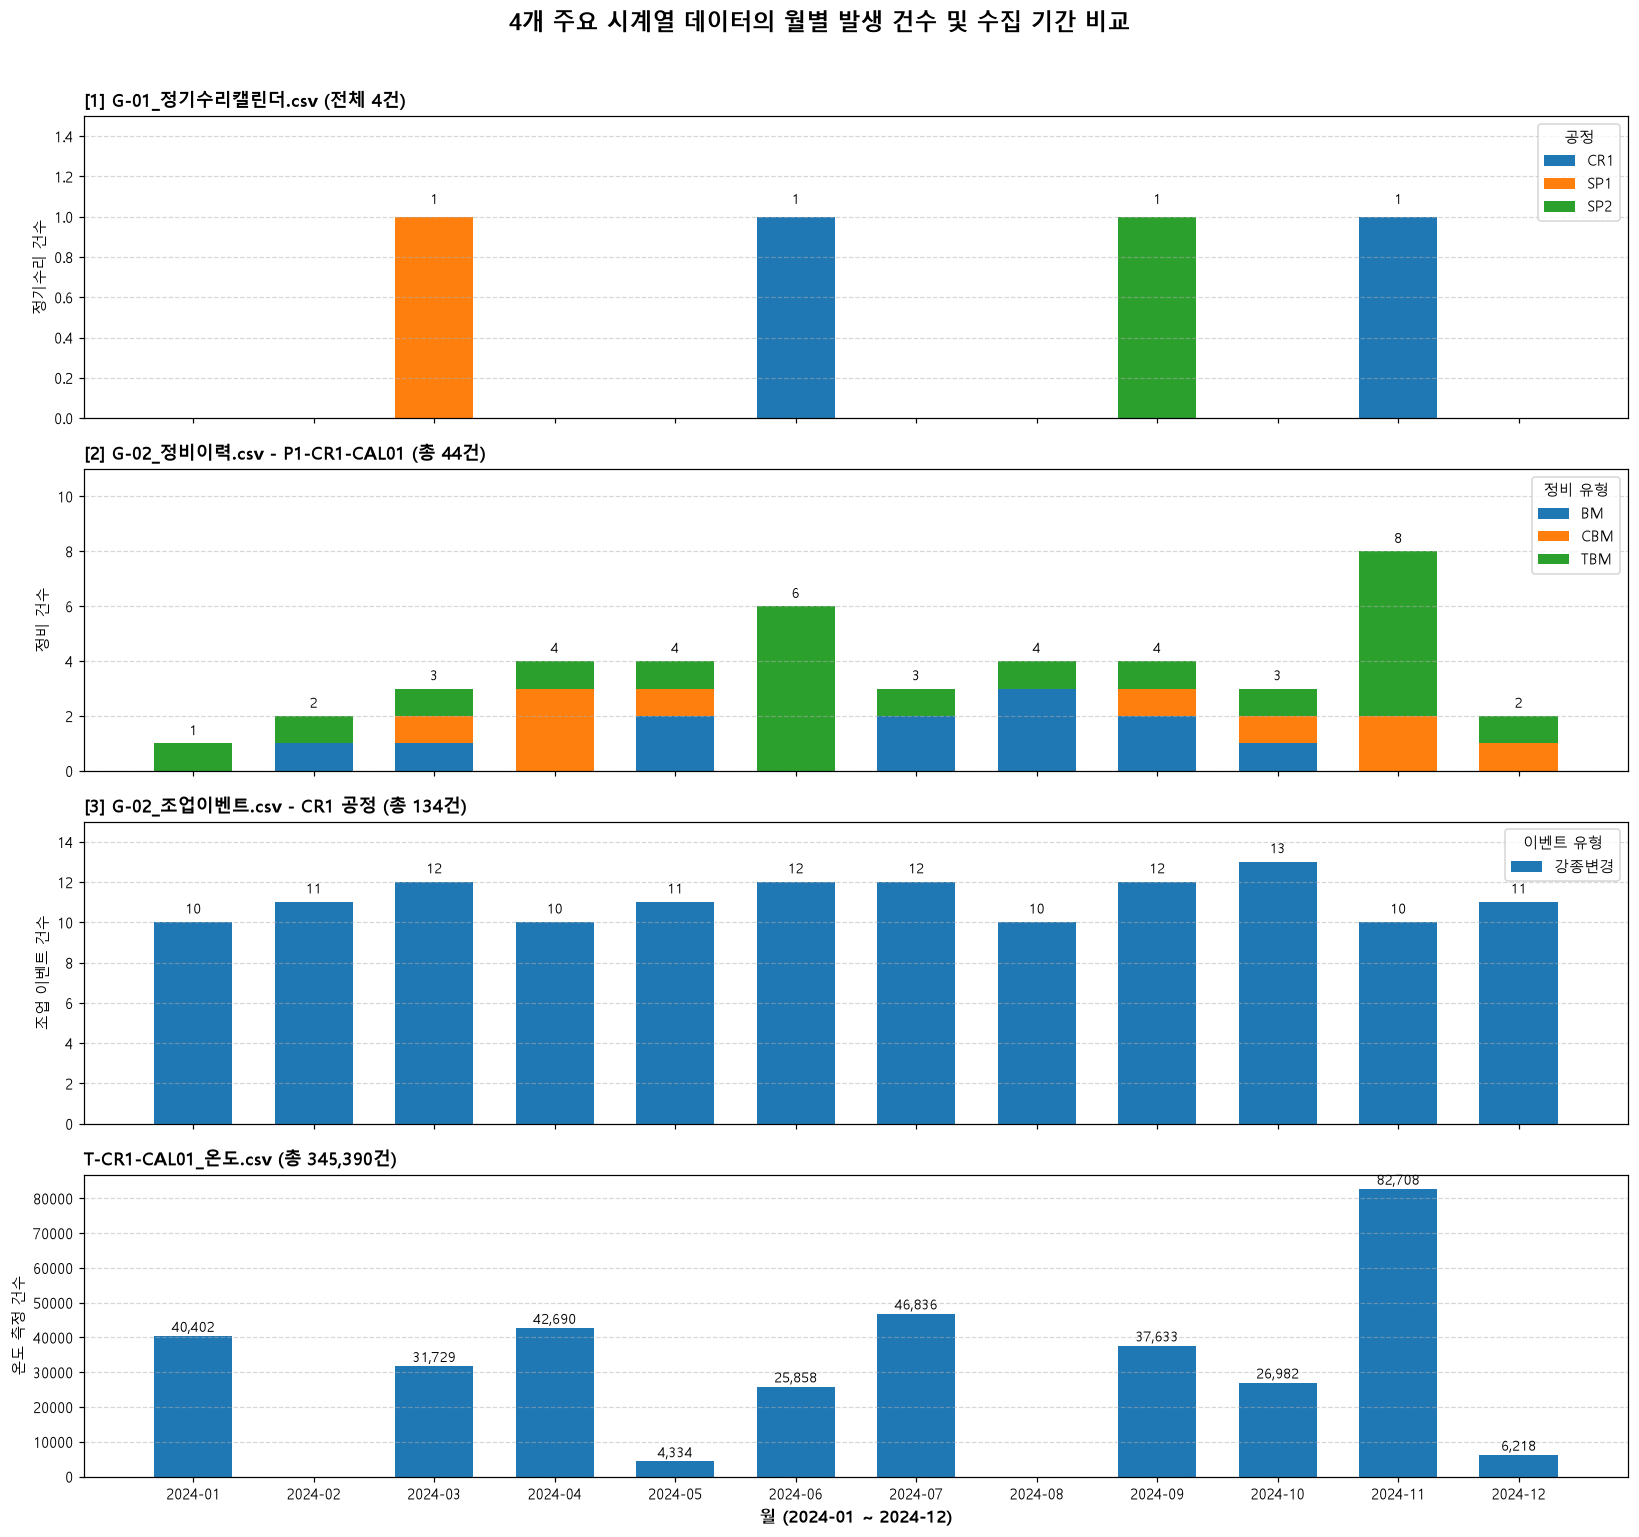

---
### 📌 가설 1. 정기수리캘린더의 공정 코드 선정과 실제 정비 대상의 일치성 검증

정기수리캘린더에는 2024년 기준 `SP1`, `CR1`, `SP2`의 공정 코드가 기록되어 있으며, 동일한 공정 코드가 모든 기간에 반복적으로 나타나는 것은 아니다.
이에 따라 정기수리캘린더에 포함된 공정 코드가 단순히 공정 간의 직접적인 연계성을 의미하는 것인지, 또는 각 공정의 주요 정기수리 대상 설비와 실제 정비 작업 범위를 대표하는 관리 기준인지를 확인하고자 한다.

특히 `CR1`의 경우 냉연 라인 내 `TCM01`, `CAL01`, `SPM01` 등의 주요 설비가 존재하므로, 정기수리 기간에 해당 설비들의 정비이력이 실제로 함께 발생하는지를 확인한다. 또한 `SP1`, `SP2`에 대해서도 정기수리캘린더의 수리 기간과 실제 정비이력의 발생 시점을 비교하여, 캘린더의 공정 코드와 실제 정비 대상 간의 대응 관계를 확인한다.

**검증 방향**

* 정기수리캘린더의 `PLANT_CD`, `STRT_DT`, `END_DT`, `SCOPE` 확인
* 설비마스터의 `PLANT_CD`, `EQP_TAG`, `PARENT_TAG`를 이용하여 공정별 주요 설비 구조 확인
* 정비이력의 `EQP_TAG`, `STRT_DT`, `END_DT`, `MNT_TYPE`를 이용하여 정기수리 기간 내 실제 정비 설비 확인
* 정기수리 기간과 실제 정비이력의 시간적 중복 여부 비교
* 공정 코드별로 정기수리 대상과 실제 정비 대상 설비가 어느 정도 대응하는지 확인


In [ ]:
# ============================================================
# 가설 1 검증
# 정기수리캘린더의 공정 코드와 실제 정비 대상의 일치성 검증
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# 1. 데이터 경로
# ------------------------------------------------------------
DATA_DIR = "../data"

REPAIR_CSV = os.path.join(DATA_DIR, "G-01_정기수리캘린더.csv")
MAINT_CSV = os.path.join(DATA_DIR, "G-02_정비이력.csv")

# ------------------------------------------------------------
# 2. 데이터 불러오기
# ------------------------------------------------------------
df_repair = pd.read_csv(REPAIR_CSV)
df_maint = pd.read_csv(MAINT_CSV)

# ------------------------------------------------------------
# 3. 날짜 형식 변환
# ------------------------------------------------------------
df_repair["STRT_DT"] = pd.to_datetime(
    df_repair["STRT_DT"], errors="coerce"
)
df_repair["END_DT"] = pd.to_datetime(
    df_repair["END_DT"], errors="coerce"
)

df_maint["STRT_DT"] = pd.to_datetime(
    df_maint["STRT_DT"], errors="coerce"
)
df_maint["END_DT"] = pd.to_datetime(
    df_maint["END_DT"], errors="coerce"
)

# ------------------------------------------------------------
# 4. 정비이력 기본 정리
# ------------------------------------------------------------
df_maint["EQP_TAG"] = df_maint["EQP_TAG"].astype(str).str.strip()
df_maint["MNT_TYPE"] = df_maint["MNT_TYPE"].astype(str).str.strip()

# DOWN_MIN 숫자 변환
df_maint["DOWN_MIN"] = pd.to_numeric(
    df_maint["DOWN_MIN"], errors="coerce"
).fillna(0)

# ------------------------------------------------------------
# 5. 정기수리 기간과 정비이력의 시간적 중복 분석
#
# 정비 작업의 시작~종료 시간이 정기수리 기간과
# 조금이라도 겹치면 "정기수리 기간 내 정비"로 판단
# ------------------------------------------------------------

summary_rows = []
detail_rows = []

for _, repair in df_repair.iterrows():

    plan_id = repair["PLAN_ID"]
    plant_cd = repair["PLANT_CD"]
    repair_start = repair["STRT_DT"]
    repair_end = repair["END_DT"]
    scope = repair["SCOPE"]

    # 날짜가 정상적으로 존재하지 않으면 제외
    if pd.isna(repair_start) or pd.isna(repair_end):
        continue

    # --------------------------------------------------------
    # 공정 코드 기준 정비이력 후보 추출
    #
    # 예:
    # CR1 → P1-CR1-...
    # SP1 → P1-SP1-...
    # SP2 → P1-SP2-...
    # --------------------------------------------------------
    plant_pattern = f"P1-{plant_cd}-"

    plant_maint = df_maint[
        df_maint["EQP_TAG"].str.startswith(
            plant_pattern, na=False
        )
    ].copy()

    # --------------------------------------------------------
    # 정기수리 기간과 실제 정비기간이 겹치는 행 추출
    #
    # overlap 조건:
    # 정비 시작 < 정기수리 종료
    # AND
    # 정비 종료 > 정기수리 시작
    # --------------------------------------------------------
    overlap = plant_maint[
        (plant_maint["STRT_DT"] < repair_end)
        & (plant_maint["END_DT"] > repair_start)
    ].copy()

    # --------------------------------------------------------
    # 요약값 계산
    # --------------------------------------------------------
    maintenance_count = len(overlap)

    total_down_min = overlap["DOWN_MIN"].sum()

    equipment_count = overlap["EQP_TAG"].nunique()

    mnt_type_count = overlap["MNT_TYPE"].value_counts().to_dict()

    # --------------------------------------------------------
    # 요약 결과 저장
    # --------------------------------------------------------
    summary_rows.append({
        "PLAN_ID": plan_id,
        "PLANT_CD": plant_cd,
        "STRT_DT": repair_start,
        "END_DT": repair_end,
        "SCOPE": scope,
        "정기수리기간_내_정비건수": maintenance_count,
        "정기수리기간_내_정비설비수": equipment_count,
        "총_DOWN_MIN": total_down_min,
        "MNT_TYPE_분포": str(mnt_type_count)
    })

    # --------------------------------------------------------
    # 상세 결과 저장
    # --------------------------------------------------------
    for _, maint in overlap.iterrows():

        detail_rows.append({
            "PLAN_ID": plan_id,
            "PLANT_CD": plant_cd,
            "정기수리_시작": repair_start,
            "정기수리_종료": repair_end,
            "EQP_TAG": maint["EQP_TAG"],
            "정비_시작": maint["STRT_DT"],
            "정비_종료": maint["END_DT"],
            "MNT_TYPE": maint["MNT_TYPE"],
            "DOWN_MIN": maint["DOWN_MIN"]
        })

# ------------------------------------------------------------
# 6. 결과 DataFrame 생성
# ------------------------------------------------------------
df_repair_summary = pd.DataFrame(summary_rows)
df_repair_detail = pd.DataFrame(detail_rows)

# ------------------------------------------------------------
# 7. 정기수리 계획별 요약 결과 출력
# ------------------------------------------------------------
print("=" * 80)
print("[가설 1 검증 결과 ①] 정기수리 계획별 실제 정비이력 대응 여부")
print("=" * 80)

display(df_repair_summary)

# ------------------------------------------------------------
# 8. 실제 정비 대상 설비 상세 출력
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("[가설 1 검증 결과 ②] 정기수리 기간 내 실제 정비 설비")
print("=" * 80)

if len(df_repair_detail) > 0:

    display(
        df_repair_detail.sort_values(
            ["PLAN_ID", "EQP_TAG", "정비_시작"]
        ).reset_index(drop=True)
    )

else:
    print("정기수리 기간과 시간적으로 중복되는 정비이력이 없습니다.")

# ------------------------------------------------------------
# 9. CR1 주요 설비(TCM01, CAL01, SPM01) 검증
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("[가설 1 검증 결과 ③] CR1 주요 설비의 정기수리 기간 내 정비 여부")
print("=" * 80)

cr1_targets = [
    "P1-CR1-TCM01",
    "P1-CR1-CAL01",
    "P1-CR1-SPM01"
]

cr1_repairs = df_repair[
    df_repair["PLANT_CD"] == "CR1"
].copy()

cr1_major_rows = []

for _, repair in cr1_repairs.iterrows():

    plan_id = repair["PLAN_ID"]
    repair_start = repair["STRT_DT"]
    repair_end = repair["END_DT"]

    for eqp in cr1_targets:

        matched = df_maint[
            (df_maint["EQP_TAG"] == eqp)
            & (df_maint["STRT_DT"] < repair_end)
            & (df_maint["END_DT"] > repair_start)
        ].copy()

        cr1_major_rows.append({
            "PLAN_ID": plan_id,
            "정기수리_시작": repair_start,
            "정기수리_종료": repair_end,
            "EQP_TAG": eqp,
            "정기수리기간_내_정비건수": len(matched),
            "총_DOWN_MIN": matched["DOWN_MIN"].sum()
        })

df_cr1_major = pd.DataFrame(cr1_major_rows)

display(df_cr1_major)

# ------------------------------------------------------------
# 10. CR1 정기수리 기간별 정비 설비 목록
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("[가설 1 검증 결과 ④] CR1 정기수리 기간별 실제 정비 설비 목록")
print("=" * 80)

for _, repair in cr1_repairs.iterrows():

    plan_id = repair["PLAN_ID"]
    repair_start = repair["STRT_DT"]
    repair_end = repair["END_DT"]

    matched = df_maint[
        (df_maint["EQP_TAG"].str.startswith(
            "P1-CR1-", na=False
        ))
        & (df_maint["STRT_DT"] < repair_end)
        & (df_maint["END_DT"] > repair_start)
    ].copy()

    print(
        f"\n{plan_id} | "
        f"{repair_start.date()} ~ {repair_end.date()}"
    )

    if len(matched) == 0:
        print("  → 정기수리 기간과 중복되는 CR1 정비이력 없음")

    else:
        equipment_list = (
            matched["EQP_TAG"]
            .value_counts()
            .sort_index()
        )

        for eqp, count in equipment_list.items():
            print(f"  - {eqp}: {count}건")

# ------------------------------------------------------------
# 11. 가설 검증에 필요한 핵심 지표만 별도로 출력
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("[가설 1 핵심 지표]")
print("=" * 80)

for _, row in df_repair_summary.iterrows():

    print(
        f"{row['PLAN_ID']} | "
        f"{row['PLANT_CD']} | "
        f"{row['STRT_DT'].date()} ~ {row['END_DT'].date()} | "
        f"정비 {row['정기수리기간_내_정비건수']}건 | "
        f"설비 {row['정기수리기간_내_정비설비수']}종 | "
        f"DOWN_MIN {row['총_DOWN_MIN']:.0f}분"
    )


### [가설 1 검증 결과 ①] 정기수리 계획별 실제 정비이력 대응 여부

| PLAN_ID | PLANT_CD | STRT_DT | END_DT | SCOPE | 정기수리기간_내_정비건수 | 정기수리기간_내_정비설비수 | 총_DOWN_MIN | MNT_TYPE_분포 |
| :--- | :---: | :---: | :---: | :--- | :---: | :---: | :---: | :--- |
| PLAN-2024-01 | SP1 | 2024-03-15 | 2024-03-22 | 배풍기 정지 및 소결기 정기점검 | 59 | 18 | 9976 | {'TBM': 58, 'CBM': 1} |
| PLAN-2024-02 | CR1 | 2024-06-10 | 2024-06-14 | 연속소둔로 노내 정비 | 37 | 14 | 5778 | {'TBM': 37} |
| PLAN-2024-03 | SP2 | 2024-09-15 | 2024-09-22 | 배풍기 정지 및 소결기 정기점검 | 63 | 18 | 9680 | {'TBM': 62, 'CBM': 1} |
| PLAN-2024-04 | CR1 | 2024-11-05 | 2024-11-10 | 냉연 라인 전 설비 정기수리 | 41 | 15 | 6422 | {'TBM': 41} |

<br>

### [가설 1 검증 결과 ②] 정기수리 기간 내 실제 정비 설비 (샘플)

| PLAN_ID | PLANT_CD | 정기수리_시작 | 정기수리_종료 | EQP_TAG | 정비_시작 | 정비_종료 | MNT_TYPE | DOWN_MIN |
| :--- | :---: | :---: | :---: | :--- | :---: | :---: | :---: | :---: |
| PLAN-2024-01 | SP1 | 2024-03-15 | 2024-03-22 | P1-SP1-AGT01 | 2024-03-15 08:51:00 | 2024-03-15 12:40:00 | TBM | 0 |
| PLAN-2024-01 | SP1 | 2024-03-15 | 2024-03-22 | P1-SP1-AGT01-MTR | 2024-03-15 05:30:00 | 2024-03-15 11:47:00 | TBM | 377 |
| PLAN-2024-01 | SP1 | 2024-03-15 | 2024-03-22 | P1-SP1-AGT01-MTR | 2024-03-17 22:03:00 | 2024-03-18 03:28:00 | TBM | 325 |
| PLAN-2024-01 | SP1 | 2024-03-15 | 2024-03-22 | P1-SP1-AGT01-MTR | 2024-03-20 18:07:00 | 2024-03-20 19:23:00 | TBM | 0 |
| PLAN-2024-01 | SP1 | 2024-03-15 | 2024-03-22 | P1-SP1-BCV01 | 2024-03-19 17:40:00 | 2024-03-19 19:32:00 | TBM | 111 |
| ... | ... | ... | ... | ... | ... | ... | ... | ... |
| PLAN-2024-04 | CR1 | 2024-11-05 | 2024-11-10 | P1-CR1-TCM01 | 2024-11-07 02:17:00 | 2024-11-07 07:03:00 | TBM | 0 |
| PLAN-2024-04 | CR1 | 2024-11-05 | 2024-11-10 | P1-CR1-TCM01 | 2024-11-08 07:20:00 | 2024-11-08 14:45:00 | TBM | 444 |
| PLAN-2024-04 | CR1 | 2024-11-05 | 2024-11-10 | P1-CR1-WLD01 | 2024-11-05 13:57:00 | 2024-11-05 19:17:00 | TBM | 225 |
| PLAN-2024-04 | CR1 | 2024-11-05 | 2024-11-10 | P1-CR1-WLD01 | 2024-11-06 07:53:00 | 2024-11-06 11:18:00 | TBM | 204 |
| PLAN-2024-04 | CR1 | 2024-11-05 | 2024-11-10 | P1-CR1-WLD01 | 2024-11-08 23:05:00 | 2024-11-09 06:00:00 | TBM | 350 |

> *주: 전체 200행 중 일부 발췌 데이터*

<br>

### [가설 1 검증 결과 ③] CR1 주요 설비의 정기수리 기간 내 정비 여부

| PLAN_ID | 정기수리_시작 | 정기수리_종료 | EQP_TAG | 정기수리기간_내_정비건수 | 총_DOWN_MIN |
| :--- | :---: | :---: | :--- | :---: | :---: |
| PLAN-2024-02 | 2024-06-10 | 2024-06-14 | P1-CR1-TCM01 | 3 | 150 |
| PLAN-2024-02 | 2024-06-10 | 2024-06-14 | P1-CR1-CAL01 | 5 | 813 |
| PLAN-2024-02 | 2024-06-10 | 2024-06-14 | P1-CR1-SPM01 | 3 | 328 |
| PLAN-2024-04 | 2024-11-05 | 2024-11-10 | P1-CR1-TCM01 | 3 | 545 |
| PLAN-2024-04 | 2024-11-05 | 2024-11-10 | P1-CR1-CAL01 | 4 | 625 |
| PLAN-2024-04 | 2024-11-05 | 2024-11-10 | P1-CR1-SPM01 | 4 | 727 |

<br>

### [가설 1 검증 결과 ④] CR1 정기수리 기간별 실제 정비 설비 목록 및 요약

#### 📊 정기수리 실적 요약

| PLAN_ID | PLANT_CD | 정기수리 기간 | 총 정비건수 | 정비 설비수 | 총 비가동 시간 (분) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| PLAN-2024-01 | SP1 | 2024-03-15 ~ 2024-03-22 | 59건 | 18종 | 9976분 |
| PLAN-2024-02 | CR1 | 2024-06-10 ~ 2024-06-14 | 37건 | 14종 | 5778분 |
| PLAN-2024-03 | SP2 | 2024-09-15 ~ 2024-09-22 | 63건 | 18종 | 9680분 |
| PLAN-2024-04 | CR1 | 2024-11-05 ~ 2024-11-10 | 41건 | 15종 | 6422분 |

#### 🛠️ 기간별 상세 정비 건수 (CR1)

| 설비 태그 (EQP_TAG) | PLAN-2024-02 <br> (06/10 ~ 06/14) | PLAN-2024-04 <br> (11/05 ~ 11/10) |
| :--- | :---: | :---: |
| **P1-CR1-CAL01** | 5건 | 4건 |
| **P1-CR1-CRN01** | 2건 | 2건 |
| **P1-CR1-DCF01** | 3건 | 5건 |
| **P1-CR1-FAN01** | 5건 | - |
| **P1-CR1-FAN02** | 2건 | - |
| **P1-CR1-INS01** | 2건 | - |
| **P1-CR1-PKL01** | 1건 | - |
| **P1-CR1-PMP01** | 3건 | - |
| **P1-CR1-PMP03** | 1건 | - |
| **P1-CR1-RCL01** | 2건 | - |
| **P1-CR1-SPM01** | 3건 | - |
| **P1-CR1-SPM01-MTR** | 1건 | - |
| **P1-CR1-TCM01** | 3건 | - |
| **P1-CR1-WLD01** | 4건 | - |


---
### 📌 가설 2. CR1 정기수리·CAL01 정비와 온도 데이터의 시간적 관계 검증

앞선 분석에서 `T-CR1-CAL01_온도.csv`는 CR1 공정의 `CAL01` 설비에서 수집된 온도 데이터임을 확인하였다. 따라서 해당 온도 데이터와의 비교에서는 다른 공정의 정기수리 및 정비이력을 제외하고, **CR1 정기수리 일정과 `P1-CR1-CAL01` 설비의 실제 정비이력**을 대상으로 분석할 필요가 있다.

월별 발생 건수 비교 결과, CR1 정기수리는 6월과 11월에 발생하였으며, CAL01 정비이력 역시 여러 시점에서 확인된다. 한편 CAL01 온도 데이터는 월별 측정 건수에 큰 차이가 있으며, 일부 월에는 데이터가 존재하지 않거나 특정 월에 측정량이 크게 증가하는 특징이 나타난다.

이에 따라 **CR1 정기수리 및 CAL01 정비가 발생한 시점과 CAL01 온도 데이터의 수집 시점 사이에 시간적 관계가 존재하는지**를 검증하고자 한다.

**검증 방향**

* `G-01_정기수리캘린더.csv`에서 `PLANT_CD = CR1`인 정기수리의 시작일과 종료일을 확인한다.
* `G-02_정비이력.csv`에서 `EQP_TAG = P1-CR1-CAL01`인 정비이력만 추출하여 실제 정비 시점과 정비시간을 확인한다.
* `T-CR1-CAL01_온도.csv`의 `MEAS_DT`를 기준으로 온도 데이터의 실제 수집 구간을 확인한다.
* CR1 정기수리 및 CAL01 정비 기간을 기준으로 온도 데이터가 **수리 전·수리 중·수리 후**에 어떻게 나타나는지 비교한다.
* 정기수리 또는 CAL01 정비 기간에 온도 데이터의 수집 중단, 감소 또는 증가가 나타나는지 확인한다.
* 이를 통해 온도 데이터의 결측 또는 측정량 변화가 정기수리·정비 시점과 **시간적으로 일치하는지**를 확인한다.

단, 시간적 일치 여부는 두 현상 간의 연관성을 판단하기 위한 근거로 활용하며, 온도 데이터의 변화가 정기수리 또는 정비의 **원인이라고 단정하지 않는다.**


### 가설 2 검증 내용

**분석 대상**

* `T-CR1-CAL01_온도.csv` : CR1 공정 CAL01 설비의 온도 데이터
* `G-01_정기수리캘린더.csv` : `PLANT_CD = CR1`인 정기수리 일정
* `G-02_정비이력.csv` : `EQP_TAG = P1-CR1-CAL01`인 CAL01 정비이력

**분석 기준**

* CR1 정기수리 기간을 기준으로 온도 데이터의 수집 여부를 확인한다.
* 정기수리 기간과 CAL01 실제 정비이력의 시간적 중복 여부를 확인한다.
* 정기수리 전·중·후의 온도 데이터 수집 현황을 비교한다.
* 정기수리 기간에 온도 데이터의 수집 중단 또는 감소가 나타나는지 확인한다.
* 정기수리 종료 후 온도 데이터가 다시 수집되는지 확인한다.

**확인할 주요 사항**

* 6월 및 11월 CR1 정기수리 기간 중 CAL01 온도 데이터의 존재 여부
* 정기수리 기간과 `P1-CR1-CAL01` 정비이력의 중복 여부
* 정기수리 전후 온도 데이터 수집 현황의 변화
* 정기수리 시점과 온도 데이터 미수집 구간 사이의 시간적 일치 여부

**판단 기준**

* 정기수리 기간에 온도 데이터가 수집되지 않고, 정기수리 전후에는 데이터가 존재한다면 두 현상 사이에 시간적 연관성이 있는 것으로 판단한다.
* 다만 온도 데이터의 미수집 또는 변화만으로 설비의 실제 가동·비가동 상태나 정기수리의 원인을 단정하지 않는다.
* 본 분석에서는 **시간적 연관성 여부를 확인하는 것**을 목적으로 하며, 두 현상 간의 인과관계는 판단하지 않는다.


In [ ]:
# ============================================================
# 가설 2 검증
# CR1 정기수리·CAL01 정비와 CAL01 온도 데이터의 시간적 관계
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. 데이터 불러오기
# ------------------------------------------------------------
DATA_DIR = "../data"

TEMP_CSV = f"{DATA_DIR}/T-CR1-CAL01_온도.csv"
REPAIR_CSV = f"{DATA_DIR}/G-01_정기수리캘린더.csv"
MAINT_CSV = f"{DATA_DIR}/G-02_정비이력.csv"

df_temp = pd.read_csv(TEMP_CSV)
df_repair = pd.read_csv(REPAIR_CSV)
df_maint = pd.read_csv(MAINT_CSV)

# ------------------------------------------------------------
# 2. 날짜/시간 형식 변환
# ------------------------------------------------------------
df_temp["MEAS_DT"] = pd.to_datetime(
    df_temp["MEAS_DT"], errors="coerce"
)

df_repair["STRT_DT"] = pd.to_datetime(
    df_repair["STRT_DT"], errors="coerce"
)
df_repair["END_DT"] = pd.to_datetime(
    df_repair["END_DT"], errors="coerce"
)

df_maint["STRT_DT"] = pd.to_datetime(
    df_maint["STRT_DT"], errors="coerce"
)
df_maint["END_DT"] = pd.to_datetime(
    df_maint["END_DT"], errors="coerce"
)

# ------------------------------------------------------------
# 3. 분석 대상 필터링
# ------------------------------------------------------------

# CR1 정기수리만 추출
df_repair_cr1 = (
    df_repair[
        df_repair["PLANT_CD"].astype(str).str.strip().eq("CR1")
    ]
    .copy()
    .sort_values("STRT_DT")
    .reset_index(drop=True)
)

# CAL01 정비이력만 추출
df_maint_cal01 = (
    df_maint[
        df_maint["EQP_TAG"].astype(str).str.strip().eq(
            "P1-CR1-CAL01"
        )
    ]
    .copy()
    .sort_values("STRT_DT")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 4. 기본 현황 확인
# ------------------------------------------------------------
print("=" * 70)
print("[분석 대상 데이터]")
print("=" * 70)

print(f"온도 데이터       : {len(df_temp):,}건")
print(f"CR1 정기수리      : {len(df_repair_cr1):,}건")
print(f"CAL01 정비이력    : {len(df_maint_cal01):,}건")

print("\n[CR1 정기수리 일정]")
print(
    df_repair_cr1[
        ["PLANT_CD", "STRT_DT", "END_DT", "SCOPE"]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# 5. 정기수리별 전·중·후 시간 구간 설정
#
# 기준:
# - DURING : 실제 정기수리 기간
# - BEFORE : 정기수리 시작 직전, 동일한 길이
# - AFTER  : 정기수리 종료 직후, 동일한 길이
# ------------------------------------------------------------

results = []

for idx, repair in df_repair_cr1.iterrows():

    repair_start = repair["STRT_DT"]
    repair_end = repair["END_DT"]

    if pd.isna(repair_start) or pd.isna(repair_end):
        continue

    duration = repair_end - repair_start

    before_start = repair_start - duration
    before_end = repair_start

    after_start = repair_end
    after_end = repair_end + duration

    # 온도 데이터의 전/중/후 구간
    temp_before = df_temp[
        (df_temp["MEAS_DT"] >= before_start) &
        (df_temp["MEAS_DT"] < before_end)
    ]

    temp_during = df_temp[
        (df_temp["MEAS_DT"] >= repair_start) &
        (df_temp["MEAS_DT"] < repair_end)
    ]

    temp_after = df_temp[
        (df_temp["MEAS_DT"] >= after_start) &
        (df_temp["MEAS_DT"] < after_end)
    ]

    # CAL01 정비이력과 정기수리 기간의 시간적 중복
    maint_overlap = df_maint_cal01[
        (df_maint_cal01["STRT_DT"] < repair_end) &
        (df_maint_cal01["END_DT"] > repair_start)
    ].copy()

    results.append({
        "정기수리_번호": idx + 1,
        "정기수리_시작": repair_start,
        "정기수리_종료": repair_end,
        "수리기간_시간": duration.total_seconds() / 3600,

        "수리전_온도건수": len(temp_before),
        "수리중_온도건수": len(temp_during),
        "수리후_온도건수": len(temp_after),

        "CAL01_정비건수": len(maint_overlap),
        "CAL01_DOWN_MIN": (
            maint_overlap["DOWN_MIN"].sum()
            if len(maint_overlap) > 0
            else 0
        ),

        "수리전_시작": before_start,
        "수리전_종료": before_end,
        "수리후_시작": after_start,
        "수리후_종료": after_end
    })

df_result = pd.DataFrame(results)

# ------------------------------------------------------------
# 6. 정기수리별 결과 출력
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[정기수리별 전·중·후 온도 데이터 비교]")
print("=" * 70)

display(
    df_result[
        [
            "정기수리_번호",
            "정기수리_시작",
            "정기수리_종료",
            "수리기간_시간",
            "수리전_온도건수",
            "수리중_온도건수",
            "수리후_온도건수",
            "CAL01_정비건수",
            "CAL01_DOWN_MIN"
        ]
    ]
)

# ------------------------------------------------------------
# 7. CAL01 정비이력 중 정기수리 기간과 겹치는 작업 상세
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[CR1 정기수리 기간과 겹치는 CAL01 정비이력]")
print("=" * 70)

for idx, repair in df_repair_cr1.iterrows():

    repair_start = repair["STRT_DT"]
    repair_end = repair["END_DT"]

    maint_overlap = df_maint_cal01[
        (df_maint_cal01["STRT_DT"] < repair_end) &
        (df_maint_cal01["END_DT"] > repair_start)
    ].copy()

    print(f"\n[정기수리 {idx + 1}]")
    print(f"기간 : {repair_start} ~ {repair_end}")
    print(f"CAL01 정비 건수 : {len(maint_overlap)}")

    if len(maint_overlap) > 0:
        display(
            maint_overlap[
                [
                    "WO_NO",
                    "EQP_TAG",
                    "STRT_DT",
                    "END_DT",
                    "MNT_TYPE",
                    "DOWN_MIN",
                    "REMARK"
                ]
            ].reset_index(drop=True)
        )
    else:
        print("해당 기간과 겹치는 CAL01 정비이력이 없습니다.")

# ------------------------------------------------------------
# 8. 온도 데이터가 실제로 존재하는 날짜 범위 확인
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[온도 데이터 전체 수집 범위]")
print("=" * 70)

print(f"최초 측정 : {df_temp['MEAS_DT'].min()}")
print(f"최종 측정 : {df_temp['MEAS_DT'].max()}")

# ------------------------------------------------------------
# 9. 월별 온도 데이터 건수
# ------------------------------------------------------------

df_temp["MONTH"] = df_temp["MEAS_DT"].dt.month

monthly_temp = (
    df_temp
    .groupby("MONTH")
    .size()
    .reindex(range(1, 13), fill_value=0)
)

print("\n" + "=" * 70)
print("[월별 CAL01 온도 데이터 건수]")
print("=" * 70)

display(
    monthly_temp.rename("온도_측정건수").to_frame()
)

# ------------------------------------------------------------
# 10. 핵심 결과 요약
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[가설 2 검증용 핵심 지표]")
print("=" * 70)

for _, row in df_result.iterrows():

    print(
        f"\n정기수리 {int(row['정기수리_번호'])} "
        f"({row['정기수리_시작']} ~ {row['정기수리_종료']})"
    )

    print(
        f"  • 수리 전 온도 데이터 : "
        f"{int(row['수리전_온도건수']):,}건"
    )

    print(
        f"  • 수리 중 온도 데이터 : "
        f"{int(row['수리중_온도건수']):,}건"
    )

    print(
        f"  • 수리 후 온도 데이터 : "
        f"{int(row['수리후_온도건수']):,}건"
    )

    print(
        f"  • 수리 기간 내 CAL01 정비 : "
        f"{int(row['CAL01_정비건수'])}건"
    )

    print(
        f"  • 수리 기간 내 CAL01 DOWN_MIN : "
        f"{row['CAL01_DOWN_MIN']:.0f}분"
    )

In [ ]:
# ============================================================
# [가설 2 보완 확인]
# 11월 온도 데이터의 정기수리 전·중·후 구간 확인
# ============================================================

# 1. 11월 온도 데이터 추출
df_temp_nov = df_temp[
    df_temp["MEAS_DT"].dt.to_period("M") == "2024-11"
].copy()

# 2. CR1 11월 정기수리 기간
repair_start = pd.Timestamp("2024-11-05 00:00:00")
repair_end = pd.Timestamp("2024-11-10 00:00:00")

# 3. 정기수리 전·중·후 구간 분류
df_temp_nov["REPAIR_PHASE"] = "정기수리 전"

df_temp_nov.loc[
    (df_temp_nov["MEAS_DT"] >= repair_start) &
    (df_temp_nov["MEAS_DT"] <= repair_end),
    "REPAIR_PHASE"
] = "정기수리 중"

df_temp_nov.loc[
    df_temp_nov["MEAS_DT"] > repair_end,
    "REPAIR_PHASE"
] = "정기수리 후"

# 4. 구간별 건수
phase_counts = (
    df_temp_nov["REPAIR_PHASE"]
    .value_counts()
    .reindex(
        ["정기수리 전", "정기수리 중", "정기수리 후"],
        fill_value=0
    )
)

print("=" * 70)
print("[11월 온도 데이터 정기수리 전·중·후 재분류 결과]")
print("=" * 70)

for phase, count in phase_counts.items():
    print(f"{phase:10s}: {count:,}건")

print("-" * 70)
print(f"11월 전체 온도 데이터 : {len(df_temp_nov):,}건")
print(f"전·중·후 합계         : {phase_counts.sum():,}건")
print(f"차이                   : {len(df_temp_nov) - phase_counts.sum():,}건")

# 5. 실제 온도 데이터의 전체 시간 범위 확인
print("\n" + "=" * 70)
print("[11월 온도 데이터 시간 범위]")
print("=" * 70)

print(f"최초 측정 : {df_temp_nov['MEAS_DT'].min()}")
print(f"최종 측정 : {df_temp_nov['MEAS_DT'].max()}")

print("\n[CR1 11월 정기수리 기간]")
print(f"시작 : {repair_start}")
print(f"종료 : {repair_end}")

# 6. 정기수리 전·중·후 데이터의 실제 시간 범위 확인
print("\n" + "=" * 70)
print("[구간별 실제 데이터 시간 범위]")
print("=" * 70)

for phase in ["정기수리 전", "정기수리 중", "정기수리 후"]:
    temp_phase = df_temp_nov[
        df_temp_nov["REPAIR_PHASE"] == phase
    ]

    print(f"\n[{phase}]")
    print(f"건수     : {len(temp_phase):,}건")

    if len(temp_phase) > 0:
        print(f"최초 측정 : {temp_phase['MEAS_DT'].min()}")
        print(f"최종 측정 : {temp_phase['MEAS_DT'].max()}")
    else:
        print("데이터 없음")

### 가설 2 검증 결과

**1. 6월 정기수리 기간**

* CR1 정기수리 기간인 **2024-06-10 ~ 2024-06-14** 동안 CAL01 온도 데이터는 **0건**으로 확인되었다.
* 정기수리 전 온도 데이터는 **12,559건**, 정기수리 후 온도 데이터는 **13,299건**으로 확인되었다.
* 동일 기간 `P1-CR1-CAL01` 정비이력은 **5건**, 총 `DOWN_MIN`은 **813분**으로 확인되었다.

**2. 11월 정기수리 기간**

* CR1 정기수리 기간인 **2024-11-05 00:00 ~ 2024-11-10 00:00** 동안 CAL01 온도 데이터는 **0건**으로 확인되었다.
* 11월 전체 CAL01 온도 데이터는 **82,708건**이며, 정기수리 전 **18,763건**, 정기수리 중 **0건**, 정기수리 후 **63,945건**으로 분류되었다.
* 실제 온도 데이터는 정기수리 시작 전인 **2024-11-04 15:40**부터 존재하며, 정기수리 종료 후 **2024-11-13 07:08**부터 다시 수집된 것으로 확인되었다.
* 동일 기간 `P1-CR1-CAL01` 정비이력은 **4건**, 총 `DOWN_MIN`은 **625분**으로 확인되었다.

**3. 종합 판단**

* 6월과 11월 모두 **CR1 정기수리 기간에 CAL01 온도 데이터가 수집되지 않았으며**, 정기수리 전후에는 온도 데이터가 존재하는 패턴이 확인되었다.
* 또한 정기수리 기간에 `P1-CR1-CAL01` 정비이력이 함께 존재하여, **정기수리 기간과 CAL01의 온도 데이터 미수집 구간 사이에 시간적 연관성이 있음**을 확인하였다.
* 특히 11월의 경우 정기수리 기간에는 온도 데이터가 **0건**이고, 정기수리 종료 후 다시 온도 데이터가 수집되는 것이 확인되어 해당 시간적 관계가 명확하게 나타났다.

**4. 가설 판단**

> **가설 2는 시간적 연관성 측면에서 지지된다.**

다만 본 분석은 정기수리 기간과 온도 데이터 미수집 구간의 **시간적 일치 여부를 확인한 것**이며, 정기수리가 온도 데이터 미수집의 직접적인 원인이라는 **인과관계까지는 판단하지 않는다.**

---

### 3-1. 정기수리 기간 파생변수 생성

가설 1과 가설 2의 검증 결과를 바탕으로 CAL01 온도 데이터의 측정시점이 CR1 정기수리 기간에 해당하는지를 나타내는 파생변수를 생성한다.

**파생변수명**

* `IS_CR1_REPAIR_PERIOD`

**생성 기준**

* `G-01_정기수리캘린더.csv`에서 `PLANT_CD = CR1`인 정기수리 기간을 사용한다.
* `T-CR1-CAL01_온도.csv`의 `MEAS_DT`가 CR1 정기수리 시작시각 이상이고 종료시각 미만이면 `1`, 그 외에는 `0`으로 정의한다.

**생성 목적**

* 가설 1에서 확인한 CR1 정기수리 기간과 실제 CAL01 정비이력의 시간적 중복 관계를 온도 데이터에 반영한다.
* 가설 2에서 확인한 CR1 정기수리 기간과 CAL01 온도 데이터 미수집 구간의 시간적 연관성을 모델 입력변수로 표현한다.
* 월 단위의 `6월/11월` 구분보다 실제 정기수리 기간을 직접 반영하여 시간적 특성을 구체적으로 표현한다.

**변수 해석**

* `1`: 해당 온도 측정시점이 CR1 정기수리 기간에 해당
* `0`: 해당 온도 측정시점이 CR1 정기수리 기간에 해당하지 않음

본 변수는 정기수리 여부 자체를 나타내는 변수이며, 정기수리의 원인이나 설비의 실제 가동상태를 직접 의미하지 않는다.

In [ ]:
# ==========================================
# 3-1. CR1 정기수리 기간 파생변수 생성
# ==========================================

# CR1 정기수리 일정만 추출
cr1_repair = df_repair[df_repair["PLANT_CD"] == "CR1"].copy()

# 날짜 형식 변환
cr1_repair["STRT_DT"] = pd.to_datetime(cr1_repair["STRT_DT"])
cr1_repair["END_DT"] = pd.to_datetime(cr1_repair["END_DT"])

# 온도 데이터 복사
df_temp_fe = df_temp.copy()

# 기본값: 정기수리 기간이 아님
df_temp_fe["IS_CR1_REPAIR_PERIOD"] = 0

# CR1 정기수리 기간에 해당하는 온도 데이터 표시
for _, repair in cr1_repair.iterrows():
    mask = (
        (df_temp_fe["MEAS_DT"] >= repair["STRT_DT"]) &
        (df_temp_fe["MEAS_DT"] < repair["END_DT"])
    )
    df_temp_fe.loc[mask, "IS_CR1_REPAIR_PERIOD"] = 1

# 생성 결과 확인
print("파생변수 생성 완료")
print(df_temp_fe["IS_CR1_REPAIR_PERIOD"].value_counts().sort_index())

# 정기수리 기간별 생성 결과 확인
for _, repair in cr1_repair.iterrows():
    mask = (
        (df_temp_fe["MEAS_DT"] >= repair["STRT_DT"]) &
        (df_temp_fe["MEAS_DT"] < repair["END_DT"])
    )
    
    print(
        f"{repair['STRT_DT'].date()} ~ {repair['END_DT'].date()} : "
        f"{mask.sum():,}건"
    )

In [ ]:
# ==========================================
# 3-2. 파생변수 정합성 검증
# ==========================================

print("### IS_CR1_REPAIR_PERIOD 정합성 검증")
print()

print("전체 온도 데이터:", f"{len(df_temp_fe):,}건")
print(
    "IS_CR1_REPAIR_PERIOD = 1:",
    f"{(df_temp_fe['IS_CR1_REPAIR_PERIOD'] == 1).sum():,}건"
)
print(
    "IS_CR1_REPAIR_PERIOD = 0:",
    f"{(df_temp_fe['IS_CR1_REPAIR_PERIOD'] == 0).sum():,}건"
)

print()
print("정기수리 기간별 온도 데이터 존재 여부")

for _, repair in cr1_repair.iterrows():
    mask = (
        (df_temp_fe["MEAS_DT"] >= repair["STRT_DT"]) &
        (df_temp_fe["MEAS_DT"] < repair["END_DT"])
    )
    
    print(
        f"- {repair['PLANT_CD']} "
        f"{repair['STRT_DT'].date()} ~ {repair['END_DT'].date()}: "
        f"{mask.sum():,}건"
    )

### 3-2. 파생변수 검증 결과

* `IS_CR1_REPAIR_PERIOD`는 CR1 정기수리 캘린더의 시작·종료 시각을 기준으로 생성하였다.
* CR1 정기수리 기간은 2024년 6월과 11월에 존재한다.
* 앞선 가설 2 검증에서 해당 정기수리 기간 동안 CAL01 온도 데이터가 수집되지 않은 것으로 확인되었다.
* 따라서 관측된 CAL01 온도 데이터에서는 `IS_CR1_REPAIR_PERIOD = 1`인 행이 존재하지 않을 수 있으며, 이는 파생변수 생성 오류가 아니라 해당 기간의 온도 데이터 미수집 현상을 반영한 결과이다.
* 본 변수는 향후 온도 데이터와 정기수리 일정의 시간적 관계를 모델 입력변수로 활용하기 위한 기초 변수로 사용한다.

---